<a href="https://colab.research.google.com/github/nijatbayramoov/Instacart_market_basket_analysis/blob/main/Nijat_Bayramov_Instacart_market_basket_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1 . Reading datasets and prepocessing

In [ ]:
instacart_orders=  pd.read_csv('/content/drive/MyDrive/Dataset/project pandas/instacart_orders.csv',sep=';')
products=pd.read_csv('/content/drive/MyDrive/Dataset/project pandas/products.csv',sep=';')
departments=pd.read_csv('/content/drive/MyDrive/Dataset/project pandas/departments.csv',sep=';')
aisles=pd.read_csv('/content/drive/MyDrive/Dataset/project pandas/aisles.csv',sep=';')
order_products=pd.read_csv('/content/drive/MyDrive/Dataset/project pandas/order_products.csv',sep=';')


In [ ]:
df = instacart_orders.merge(order_products, on='order_id')
df = df.merge(products, on='product_id')
df = df.merge(aisles, on='aisle_id')
df = df.merge(departments, on='department_id')
df.head(2)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,1515936,183418,11,6,13,30.0,19048,1.0,1,Organic Butternut Squash,83,4,fresh vegetables,produce
1,1515936,183418,11,6,13,30.0,47766,3.0,1,Organic Avocado,24,4,fresh fruits,produce


## Find and remove duplicate values (and describe why you make your choices)

In [ ]:
# Check for duplicated orders

In [ ]:
df.duplicated().sum()

np.int64(146)

There are 146 fully duplicated rows in the orders table

In [ ]:
# Check for all orders placed Wednesday at 2:00 AM
df[(df['order_dow']==3) & (df['order_hour_of_day']==2)].head(2)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
46404,2766110,162084,41,3,2,16.0,10851,6.0,1,Natural Alpine Spring Water,115,7,water seltzer sparkling water,beverages
46405,2766110,162084,41,3,2,16.0,5782,5.0,0,Grade A Large White Eggs,86,16,eggs,dairy eggs


In [ ]:
# Remove duplicate orders
df=df.drop_duplicates(keep='first')
df.head(2)


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,1515936,183418,11,6,13,30.0,19048,1.0,1,Organic Butternut Squash,83,4,fresh vegetables,produce
1,1515936,183418,11,6,13,30.0,47766,3.0,1,Organic Avocado,24,4,fresh fruits,produce


In [ ]:
# Double check for duplicate order IDs only
instacart_orders.duplicated(subset='order_id').sum()

np.int64(15)

15 duplicated order_id were found when compared case-insensitively.

In [ ]:
# Check for just duplicate product IDs
products.duplicated(subset='product_id').sum()

np.int64(0)

The result i 0, confirming that all product IDs are unique.

In [ ]:
# Check for just duplicate product names (convert names to lowercase to compare better)
products['product_name'].str.lower().duplicated().sum()

np.int64(1361)

1361 duplicated product names were found when compared case-insensitively.

In [ ]:
# Check for duplicate product names that aren't missing
df[df['product_name'].notna()]['product_name'].str.lower().duplicated().sum()

np.int64(4490943)

In [ ]:
# Are all of the missing product names associated with aisle ID 100?


In [ ]:
products[products.isna().any(axis=1)]['aisle_id'].unique()

array([100])

In [ ]:
# What is this ailse and department?
products[products.isna().any(axis=1)]['department_id'].unique()==21

array([ True])

In [ ]:
# Fill missing product names with 'Unknown'
df['product_name']=df['product_name'].fillna('Unknown')
df.head(2)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,1515936,183418,11,6,13,30.0,19048,1.0,1,Organic Butternut Squash,83,4,fresh vegetables,produce
1,1515936,183418,11,6,13,30.0,47766,3.0,1,Organic Avocado,24,4,fresh fruits,produce


In [ ]:
# Are there any missing values where it's not a customer's first order?
df[(df['days_since_prior_order'].isna()) & (df['order_number']!=1)]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department


The result is empty, meaning missing values occur only for first orders and this is normal.

In [ ]:
# What are the min and max values in this column?
df['add_to_cart_order'].max()
df['add_to_cart_order'].min()
print(order_products['add_to_cart_order'].max())
print(order_products['add_to_cart_order'].min())

64.0
1.0


The values range from 1 to 64, indicating that products are normally added in positions 1 through 64.

In [ ]:
# Save all order IDs with at least one missing value in 'add_to_cart_order'
missing_add_id=df[df['add_to_cart_order'].isna()]['order_id'].unique()
missing_add_id

array([1916118,  165801,  264710, 3308010, 2999801, 1169835, 2256933,
       2449164, 1888628, 1302315,  678116, 2721963, 1386261,  733526,
        854647, 2979697, 3347453,  747668, 1677118, 2729254, 1220886,
       1717990,    9310, 1564093, 1021563,  903110, 1529171, 1598369,
       3383594, 1713430,  171934, 2926893, 1308785, 1038146, 2409109,
        404157, 2479011, 2136777, 1800005, 1730767, 2621907,   61355,
       1959075,  293169,  813364,  936852, 2849370,  888470,  180546,
       1625713, 2170451,  102236, 2997021, 2652650,  388234, 1832957,
       2094761, 1673227, 3125735,  129627, 2470674, 1183255,  871281,
       1648217, 1633337, 1968313, 1961723, 1477139,  844733, 2625444])

The output is an array of order IDs where the cart position is missing.

In [ ]:
# Do all orders with missing values have more than 64 products?
df[df['add_to_cart_order'].isna()][['order_id']]
df[df['add_to_cart_order']==64].head(2)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
180338,1916118,166951,15,1,9,14.0,27695,64.0,0,Natural Chicken & Sage Breakfast Sausage,106,12,hot dogs bacon sausage,meat seafood
339728,165801,180033,1,1,14,NaN,38596,64.0,0,Part Skim Ricotta Cheese,108,16,other creams cheeses,dairy eggs


The result is True, meaning all affected orders exceed 64 products.

In [ ]:
# Replace missing values with 999 and convert column to integer type
order_group_by=order_products.groupby("order_id")["product_id"].count()
(np.sort(order_group_by[order_group_by>64].index)==np.sort(missing_add_id)).all()

np.True_

# Note order datafram has relatively large entity .  I see  that there are no missing values . Therefore I belive the analyze will be easy

# 2. Analyze


# [A] Easy (must complete all to pass)

### [A1] Verify that the `'order_hour_of_day'` and `'order_dow'` values in the `orders` tables are sensible (i.e. `'order_hour_of_day'` ranges from 0 to 23 and `'order_dow'` ranges from 0 to 6)

In [ ]:
df[['order_hour_of_day', 'order_dow']].describe().round(0).head(2)

,order_hour_of_day,order_dow
count,4545007.0,4545007.0
mean,13.0,3.0


In [ ]:
print(f'minimum of "order_hour_of_day" : {df['order_hour_of_day'].min()}')
print(f'maximum of "order_hour_of_day" : {df['order_hour_of_day'].max()}')

minimum of "order_hour_of_day" : 0
maximum of "order_hour_of_day" : 23


### [A2] What time of day do people shop for groceries?

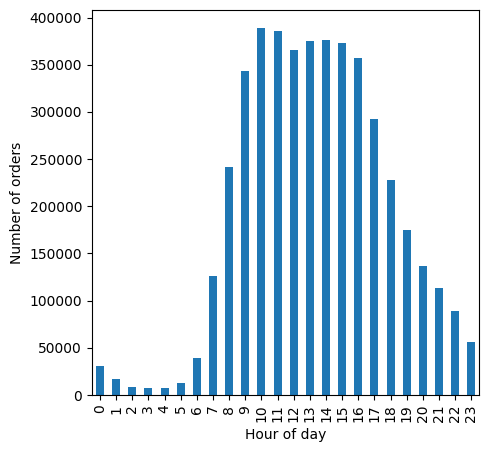

In [ ]:
plt.figure(figsize=(5, 5))
df['order_hour_of_day'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Hour of day")
plt.ylabel("Number of orders")
plt.show()

The bar chart illustrates the distribution of grocery orders across different hours of the day.
It can be observed that order activity is very low during late night and early morning hours (around 0–5 AM).
Order frequency begins to increase significantly after 7 AM and reaches its peak between approximately 10 AM and 4 PM.
After 5 PM, the number of orders gradually decreases toward the late evening hours.
This indicates that most customers prefer to shop during daytime hours, particularly in the late morning and early afternoon.

### [A3] What day of the week do people shop for groceries?

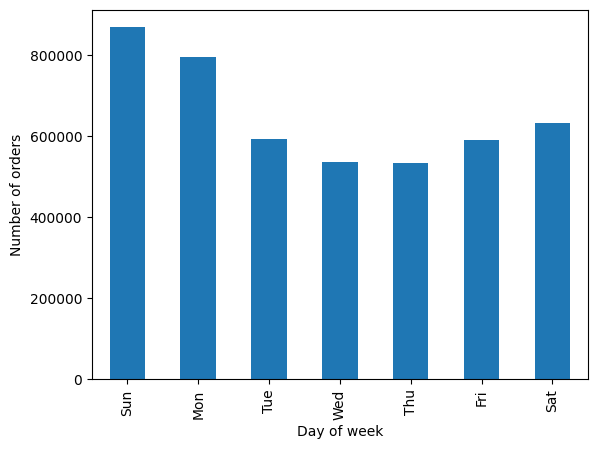

In [ ]:
day_map = {0:"Sun", 1:"Mon", 2:"Tue", 3:"Wed", 4:"Thu", 5:"Fri", 6:"Sat"}

dow_counts = df["order_dow"].value_counts().sort_index()

dow_counts.index = dow_counts.index.map(day_map)

dow_counts = dow_counts.reindex(["Sun","Mon","Tue","Wed","Thu","Fri","Sat"])

dow_counts.plot(kind="bar")
plt.xlabel("Day of week")
plt.ylabel("Number of orders")
plt.show()


The bar chart shows the distribution of grocery orders across the days of the week.
It can be observed that order activity is highest on Sunday and Monday.
After Monday, the number of orders gradually decreases, reaching lower levels midweek (especially Wednesday and Thursday).
A slight increase is observed again toward Friday and Saturday.
This indicates that customers tend to shop more at the beginning of the week, particularly on Sunday and Monday.

### [A4] How long do people wait until placing another order?

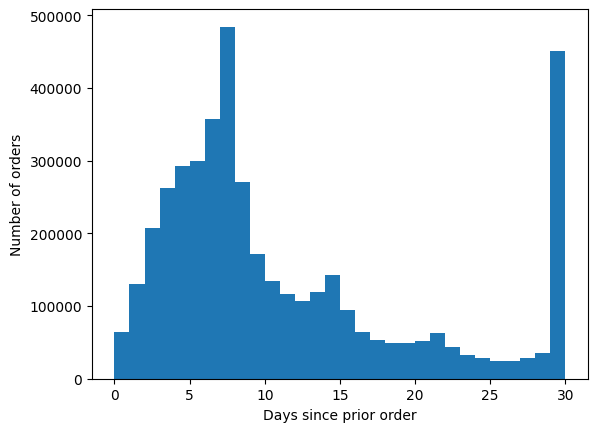

In [ ]:
df["days_since_prior_order"].plot(kind="hist", bins=30)
plt.xlabel("Days since prior order")
plt.ylabel("Number of orders")
plt.show()

The histogram shows the distribution of the number of days customers wait before placing a new order.
A high concentration of orders appears within the first 7–10 days, indicating that many customers reorder within a week.
There is also a noticeable peak at 30 days, suggesting that a significant number of customers follow a monthly purchasing pattern.
Overall, most reorders occur within the first two weeks after the previous purchase.

# [B] Medium (must complete all to pass)

### [B1] Is there a difference in `'order_hour_of_day'` distributions on Wednesdays and Saturdays? Plot the histograms for both days and describe the differences that you see.

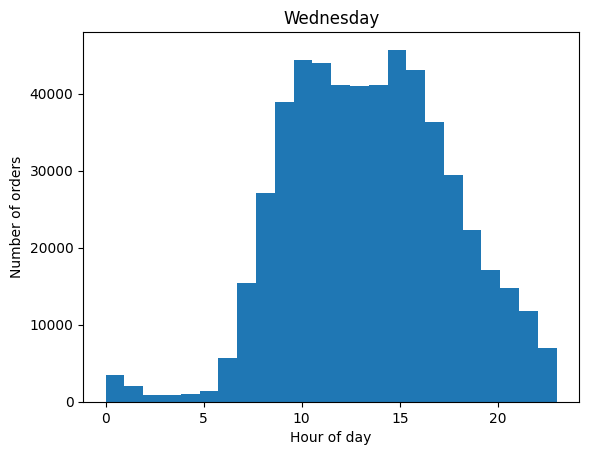

In [ ]:
df[df["order_dow"] == 3]["order_hour_of_day"].plot(kind="hist", bins=24)
plt.xlabel("Hour of day")
plt.ylabel("Number of orders")
plt.title("Wednesday")
plt.show()


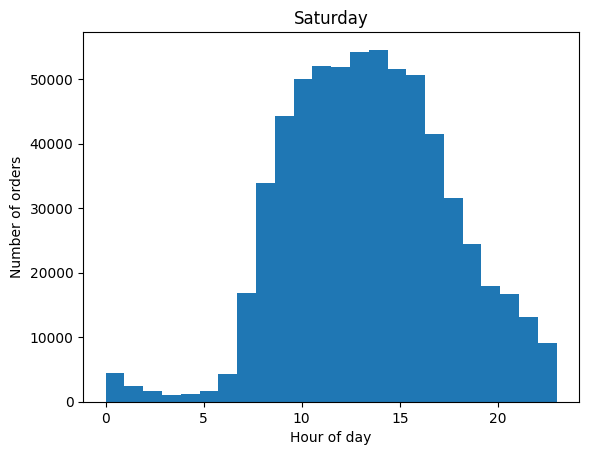

In [ ]:
df[df["order_dow"] == 6]["order_hour_of_day"].plot(kind="hist", bins=24)
plt.xlabel("Hour of day")
plt.ylabel("Number of orders")
plt.title("Saturday")
plt.show()

The histograms for Wednesday and Saturday show generally similar patterns, with order activity concentrated during daytime hours.

### [B2] What's the distribution for the number of orders per customer?

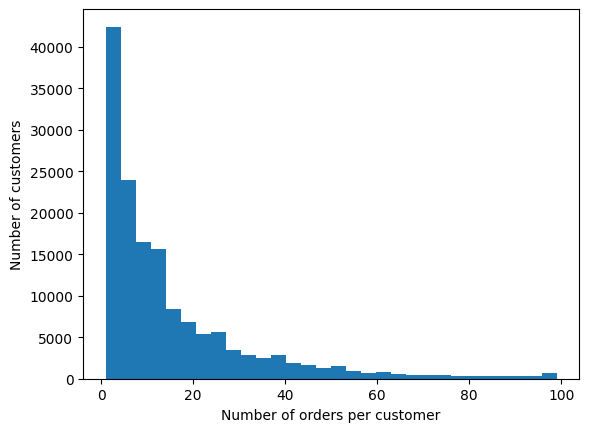

In [ ]:
orders_per_customer = df.groupby("user_id")["order_number"].max()

orders_per_customer.plot(kind="hist", bins=30)
plt.xlabel("Number of orders per customer")
plt.ylabel("Number of customers")
plt.show()

The histogram shows that most customers place a relatively small number of orders.
A large concentration of users falls within the lower order ranges (approximately 1–20 orders).
Overall, the distribution demonstrates that while most customers order occasionally, a smaller segment contributes to repeated and frequent purchases.

### [B3] What are the top 20 popular products (display their id and name)?

In [ ]:
top20=df["product_id"].value_counts().head(20).reset_index().head(2)
top20

,product_id,count
0,24852,66050
1,13176,53297


In [ ]:
top20=df.groupby(["product_id", "product_name"]).size().reset_index(name='count').sort_values(by='count', ascending=False).head(20)
top20

,product_id,product_name,count
22808,24852,Banana,66050
12025,13176,Bag of Organic Bananas,53297
19370,21137,Organic Strawberries,37039
20077,21903,Organic Baby Spinach,33971
43271,47209,Organic Hass Avocado,29773
43788,47766,Organic Avocado,24689
43663,47626,Large Lemon,21495
15364,16797,Strawberries,20018
24047,26209,Limes,19690
25556,27845,Organic Whole Milk,19600


The results show that fresh produce dominates the list of the most popular products.Bananas (product_id: 24852) rank first with 66,050 orders, followed by Bag of Organic Bananas and Organic Strawberries.A significant proportion of the top 20 products consists of organic fruits and vegetables, such as Organic Baby Spinach, Organic Hass Avocado, Organic Whole Milk, and Organic Blueberries.Overall, the ranking suggests that essential grocery staples—particularly fruits and vegetables—are the most frequently purchased items.

# [C] Hard (must complete at least two to pass)

### [C1] How many items do people typically buy in one order? What does the distribution look like?

In [ ]:
values=df.groupby('order_id')['product_id'].count().sort_values(ascending=False)
values.describe()

,product_id
count,450046.000000
mean,10.098983
std,7.540206
min,1.000000
25%,5.000000
50%,8.000000
75%,14.000000
max,127.000000


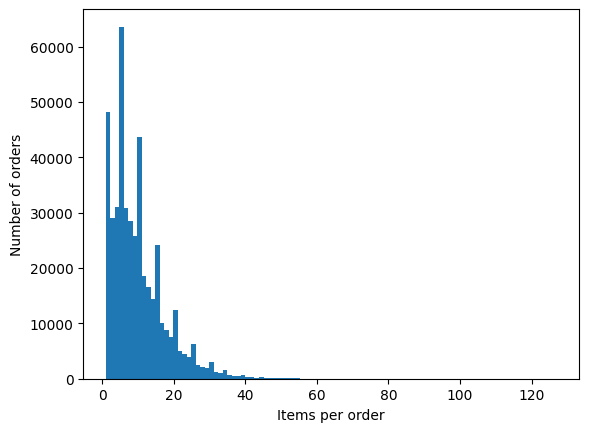

In [ ]:
values.plot(kind="hist", bins=100)
plt.xlabel("Items per order")
plt.ylabel("Number of orders")
plt.show()

### [C2] What are the top 20 items that are reordered most frequently (display their names and product IDs)?

In [ ]:
top20_most_freq=df.groupby('product_id')['reordered'].sum().sort_values(ascending=False).reset_index().head(20)
top20_most_freq

,product_id,reordered
0,24852,55763
1,13176,44450
2,21137,28639
3,21903,26233
4,47209,23629
5,47766,18743
6,27845,16251
7,47626,15044
8,27966,14748
9,16797,13945


The results show that the most frequently reordered items largely overlap with the overall most popular products.Bananas rank first with 55,763 reorders, followed by Bag of Organic Bananas and Organic Strawberries.The high reorder counts suggest that these products are staple goods that customers purchase regularly.Overall, the findings demonstrate consistent repurchasing behavior, particularly for fruits, vegetables, and everyday essentials.

### [C3] For each product, what proportion of its orders are reorders?

In [ ]:
most_freq_prop=df.groupby('product_id')['reordered'].mean().sort_values(ascending=False).reset_index()
most_freq_prop=most_freq_prop.merge(products[['product_id','product_name']],on='product_id',how='left')
most_freq_prop

,product_id,reordered,product_name
0,30644,1.0,Organic French Roast
1,8054,1.0,Bissli Smokey Wheat Snacks
2,30650,1.0,Mushroom Lover's Veggie Burgers
3,44747,1.0,Frozen Organic Blackberries
4,44743,1.0,Real Zero Cola
...,...,...,...
45568,24675,0.0,Gas & Bloating- Vegetarian Capsules
45569,24676,0.0,Maui Coconut Raspberry
45570,24688,0.0,Healthy White Clean Mint Vibrant Anticavity Mo...
45571,11290,0.0,Sea Salt & Vinegar Olive Oil Potato Chips


### [C4] For each customer, what proportion of their products ordered are reorders?

In [ ]:
user_reorder_prop=df.groupby('user_id')['reordered'].mean().sort_values(ascending=False)
user_reorder_prop.head()

,reordered
user_id,
206164,1.0
17973,1.0
196795,1.0
196792,1.0
196791,1.0


The descriptive statistics indicate that, on average, approximately 49% of the products ordered by a customer are reorders.
Also mean and median are  approximately same.

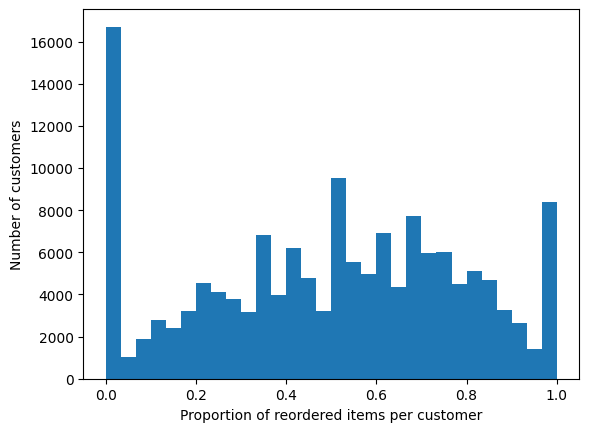

In [ ]:
user_reorder_prop.plot(kind="hist", bins=30)
plt.xlabel("Proportion of reordered items per customer")
plt.ylabel("Number of customers")
plt.show()

The histogram reveals a polarized distribution of reorder proportions across customers.
A significant spike appears at 0, indicating that a considerable number of customers never reorder products and primarily purchase new items.
At the same time, there is noticeable density across mid-range values (approximately 0.3–0.8), suggesting that many customers reorder a moderate portion of their products. Additionally, another visible concentration near 1.0 indicates that some customers almost exclusively reorder previously purchased items.

### [C5] What are the top 20 items that people put in their carts first?

In [ ]:
first_product=df.groupby('product_id')['add_to_cart_order'].sum().sort_values(ascending=False).reset_index()
first_product=first_product.merge(products[['product_id','product_name']],on='product_id',how='left')
first_product.head(20)

,product_id,add_to_cart_order,product_name
0,24852,321962.0,Banana
1,13176,271774.0,Bag of Organic Bananas
2,21137,268494.0,Organic Strawberries
3,21903,254234.0,Organic Baby Spinach
4,47209,201977.0,Organic Hass Avocado
5,47626,171731.0,Large Lemon
6,26209,170864.0,Limes
7,47766,160678.0,Organic Avocado
8,16797,141625.0,Strawberries
9,27966,138046.0,Organic Raspberries


The analysis shows that customers most frequently add "Banana" and "Bag of Organic Bananas" as the very first item in their shopping carts. The top 20 list is heavily dominated by organic fresh produce and essential dairy products, which clearly highlights the healthy eating habits and preferences of the user base. Since these specific products act as session starters, maintaining their optimal inventory level is critical for ensuring customer satisfaction and reducing cart abandonment. Leveraging these first-click items to trigger personalized cross-selling recommendations can significantly enhance the platform's conversion rate and average order value.